# 02 - Morph Generation

This notebook generates face morphs using the official implementations
provided by the original authors mapping the co author repo for all morph generator models.

Implemented morph generators:

- Greedy
- MIPGAN-II
- UBO

Inputs:

- Dataset/
- image-output/

Outputs:

- image-output/*/morph/

Expected Runtime:

- Demo Mode: 5–20 minutes
- Full Dataset: Several hours

GPU Required:

- Depends on morph implementation

### This Notebook referred Morph Generation from:
https://github.com/Blazkowiz47/morph_generator

Credits: Sushrut Patwardhan

## Morph Generation Protocol

Morphs are generated using the official implementations supplied by the
co-authors.

For every selected image pair:

S1 + S2

the following morphs are created:

- Greedy
- MIPGAN-II
- UBO

Generated morphs are mirrored into the RRPR directory structure.

## Image Output Directory Structure

All generated morphs should be mirrored in `{Working Directory}/img-output` while preserving the same directory hierarchy as their corresponding source images.

### Morphs Generated from Original Bona Fide Images

Morph images generated from the original enrolment images should be stored under:

```text
img-output/
└── {DATASET}/
    └── original/
        └── morph/
            ├── greedy/
            │   ├── train/
            │   └── test/
            ├── ubo/
            │   ├── train/
            │   └── test/
            └── mipgan2/
                ├── train/
                └── test/
```

### Morphs Generated from Perturbed Enrolment Images

Morph images generated from perturbed enrolment images should be stored within their respective perturbation directories:

```text
img-output/
└── {DATASET}/
    ├── Weighted_Ensemble_Template_PGD/
    │   └── morph/
    │       ├── greedy/
    │       ├── ubo/
    │       └── mipgan2/
    │
    ├── Weighted_Ensemble_Template_DCT_HF/
    │   └── morph/
    │       ├── greedy/
    │       ├── ubo/
    │       └── mipgan2/
    │
    ├── Weighted_Ensemble_Template_DWT_HF/
    │   └── morph/
    │       ├── greedy/
    │       ├── ubo/
    │       └── mipgan2/
    │
    └── Weighted_Ensemble_Template_BPDA_EOT/
        └── morph/
            ├── greedy/
            ├── ubo/
            └── mipgan2/
```

## Final `img-output` Directory Layout

After perturbation generation and morph synthesis, the final `img-output` directory structure should resemble the following:

```text
img-output/
├── FERET/
│   ├── original/
│   │   ├── aligned/
│   │   │   ├── train/
│   │   │   └── test/
│   │   └── morph/
│   │       ├── greedy/
│   │       ├── ubo/
│   │       └── mipgan2/
│   │
│   ├── Weighted_Ensemble_Template_PGD/
│   │   ├── aligned/
│   │   │   ├── train/
│   │   │   └── test/
│   │   └── morph/
│   │       ├── greedy/
│   │       ├── ubo/
│   │       └── mipgan2/
│   │
│   ├── Weighted_Ensemble_Template_DCT_HF/
│   │   ├── aligned/
│   │   └── morph/
│   │
│   ├── Weighted_Ensemble_Template_DWT_HF/
│   │   ├── aligned/
│   │   └── morph/
│   │
│   └── Weighted_Ensemble_Template_BPDA_EOT/
│       ├── aligned/
│       └── morph/
│
└── FRGC/
    ├── original/
    │   ├── aligned/
    │   └── morph/
    │
    ├── Weighted_Ensemble_Template_PGD/
    │   ├── aligned/
    │   └── morph/
    │
    ├── Weighted_Ensemble_Template_DCT_HF/
    │   ├── aligned/
    │   └── morph/
    │
    ├── Weighted_Ensemble_Template_DWT_HF/
    │   ├── aligned/
    │   └── morph/
    │
    └── Weighted_Ensemble_Template_BPDA_EOT/
        ├── aligned/
        └── morph/
```

> **Note:** This directory structure serves as the input for all subsequent stages of the pipeline, including embedding extraction, delta-embedding generation, face recognition evaluation, D-MAD experiments, and GMAP computation.


## Visualization

In [1]:
try:
    from google.colab import drive

    drive.mount("/content/drive")

    print("Google Drive mounted.")

except ImportError:

    print("Running outside Colab. Drive mount skipped.")

Mounted at /content/drive


In [2]:
from pathlib import Path
import os
import sys
import random
import logging
import shutil
from collections import defaultdict
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

# Seed
RANDOM_SEED = 0
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Configuration

Update project paths before execution.

Required directories:

- Dataset/
- image-output/
- repos/

In [3]:
# Update accordingly

PROJECT_ROOT = Path("/content/drive/MyDrive/Free-Cloud/ICPR_Rep")
DATASET_ROOT = PROJECT_ROOT / "Dataset"
OUTPUT_ROOT = PROJECT_ROOT / "image-output"
MODELS_DIR = PROJECT_ROOT / "models"
REPOS_DIR = PROJECT_ROOT / "repos"
METADATA_DIR = OUTPUT_ROOT / "metadata"

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)

/content/drive/MyDrive/Free-Cloud/ICPR_Rep


## Visual Verification

The following figures display:

- Source image 1
- Generated morph
- Source image 2

for randomly selected pairs.

These visualizations are intended as a sanity check before downstream
embedding extraction.

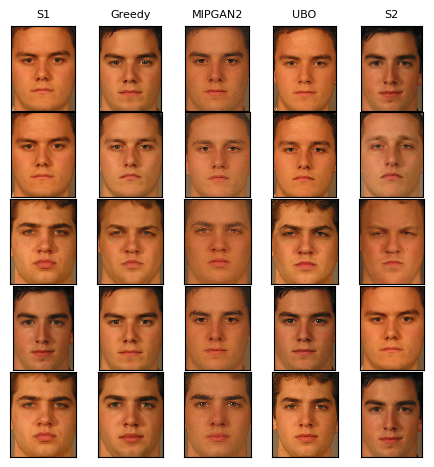

In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

NUM_SAMPLES = 5
dataset = "FRGC"
split = "train"

greedy_root = OUTPUT_ROOT / dataset / "original" / "morph" / "greedy" / split

morph_files = sorted(list(greedy_root.glob("*.png")))
morph_files = random.sample(morph_files, min(NUM_SAMPLES, len(morph_files)))

IMG_SIZE = 112

fig, axes = plt.subplots(
    len(morph_files),
    5,
    figsize=(5 * IMG_SIZE / 100, len(morph_files) * IMG_SIZE / 100),
    dpi=100
)

if len(morph_files) == 1:
    axes = np.expand_dims(axes, axis=0)

titles = ["S1", "Greedy", "MIPGAN2", "UBO", "S2"]

for row_idx, greedy_file in enumerate(morph_files):
    morph_name = greedy_file.stem
    source1_id, source2_id = morph_name.split("-vs-")

    source1_path = OUTPUT_ROOT / dataset / "original" / "aligned" / split / f"{source1_id}.png"
    source2_path = OUTPUT_ROOT / dataset / "original" / "aligned" / split / f"{source2_id}.png"
    greedy_path  = OUTPUT_ROOT / dataset / "original" / "morph" / "greedy" / split / f"{morph_name}.png"
    mipgan_path  = OUTPUT_ROOT / dataset / "original" / "morph" / "mipgan2" / split / f"{morph_name}.png"
    ubo_path     = OUTPUT_ROOT / dataset / "original" / "morph" / "ubo" / split / f"{morph_name}.png"

    image_paths = [source1_path, greedy_path, mipgan_path, ubo_path, source2_path]

    for col_idx, img_path in enumerate(image_paths):
        ax = axes[row_idx][col_idx]

        if img_path.exists():
            img = np.array(Image.open(img_path))
            ax.imshow(img, interpolation="nearest")

        ax.set_xticks([])
        ax.set_yticks([])

        if row_idx == 0:
            ax.set_title(titles[col_idx], fontsize=8)

plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()

## Morphs Across RRPR Perturbations

The following visualization displays:

Rows:
- Original
- PGD
- DCT-HF
- DWT-HF
- BPDA-EOT

Columns:
- Source 1
- Greedy
- MIPGAN-II
- UBO
- Source 2

for a single identity pair.

Selected Morph: 04496_1-vs-04411_1.png


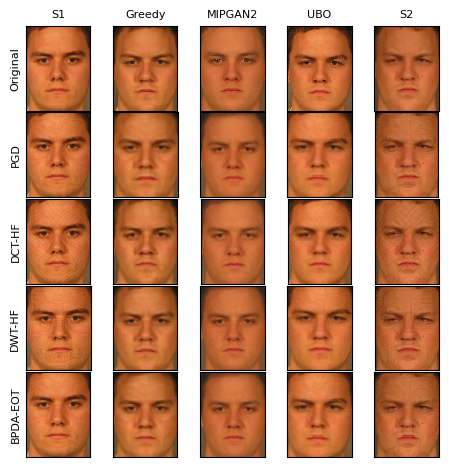

In [5]:
# Visualization: Morphs Across Perturbations
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

dataset = "FRGC"
split = "train"

PERTURBATIONS = [
    "original",
    "Weighted_Ensemble_Template_PGD",
    "Weighted_Ensemble_Template_DCT_HF",
    "Weighted_Ensemble_Template_DWT_HF",
    "Weighted_Ensemble_Template_BPDA_EOT"
]

ROW_NAMES = ["Original", "PGD", "DCT-HF", "DWT-HF", "BPDA-EOT"]
COL_NAMES = ["S1", "Greedy", "MIPGAN2", "UBO", "S2"]

# -----------------------------------------------------------------------------
# Select one morph pair from original/greedy
# -----------------------------------------------------------------------------

greedy_root = OUTPUT_ROOT / dataset / "original" / "morph" / "greedy" / split
morph_files = sorted(list(greedy_root.glob("*.png")))
selected_morph = random.choice(morph_files)

print("Selected Morph:", selected_morph.name)

morph_name = selected_morph.stem
source1_id, source2_id = morph_name.split("-vs-")

# -----------------------------------------------------------------------------
# Figure
# -----------------------------------------------------------------------------

IMG_SIZE = 112

fig, axes = plt.subplots(
    len(PERTURBATIONS),
    5,
    figsize=(5 * IMG_SIZE / 100, len(PERTURBATIONS) * IMG_SIZE / 100),
    dpi=100
)

for row_idx, perturbation in enumerate(PERTURBATIONS):
    source1_path = OUTPUT_ROOT / dataset / perturbation / "aligned" / split / f"{source1_id}.png"
    source2_path = OUTPUT_ROOT / dataset / perturbation / "aligned" / split / f"{source2_id}.png"
    greedy_path  = OUTPUT_ROOT / dataset / perturbation / "morph" / "greedy" / split / f"{morph_name}.png"
    mipgan_path  = OUTPUT_ROOT / dataset / perturbation / "morph" / "mipgan2" / split / f"{morph_name}.png"
    ubo_path     = OUTPUT_ROOT / dataset / perturbation / "morph" / "ubo" / split / f"{morph_name}.png"

    image_paths = [source1_path, greedy_path, mipgan_path, ubo_path, source2_path]

    for col_idx, img_path in enumerate(image_paths):
        ax = axes[row_idx][col_idx]

        if img_path.exists():
            img = np.array(Image.open(img_path))
            ax.imshow(img, interpolation="nearest")

        ax.set_xticks([])
        ax.set_yticks([])

        if row_idx == 0:
            ax.set_title(COL_NAMES[col_idx], fontsize=8)

        if col_idx == 0:
            ax.set_ylabel(ROW_NAMES[row_idx], fontsize=8, rotation=90)

plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()

## Next Step

After morph generation:

Run:

03_extract_embeddings.ipynb

to generate embeddings for:

- AdaFace
- ArcFace
- MagFace
- ElasticFace
- EdgeFace